# MLP Classification on Image Features

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from skimage.feature import hog
import wandb

## Dataset Analysis and Preprocessing

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

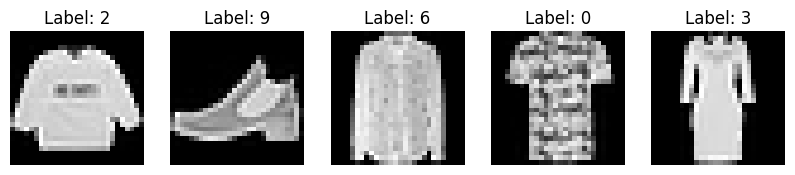

In [4]:
train_images = train.drop('label', axis=1).values
train_labels = train['label'].values

test_images = test.drop('label', axis=1).values
test_labels = test['label'].values

train_images = train_images.reshape(-1, 28, 28)
test_images = test_images.reshape(-1, 28, 28)

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f'Label: {train_labels[i]}')
    plt.axis('off')
plt.show()

np.random.seed(42)
shuffle_index = np.random.permutation(len(train_images))
train_images, train_labels = train_images[shuffle_index], train_labels[shuffle_index]


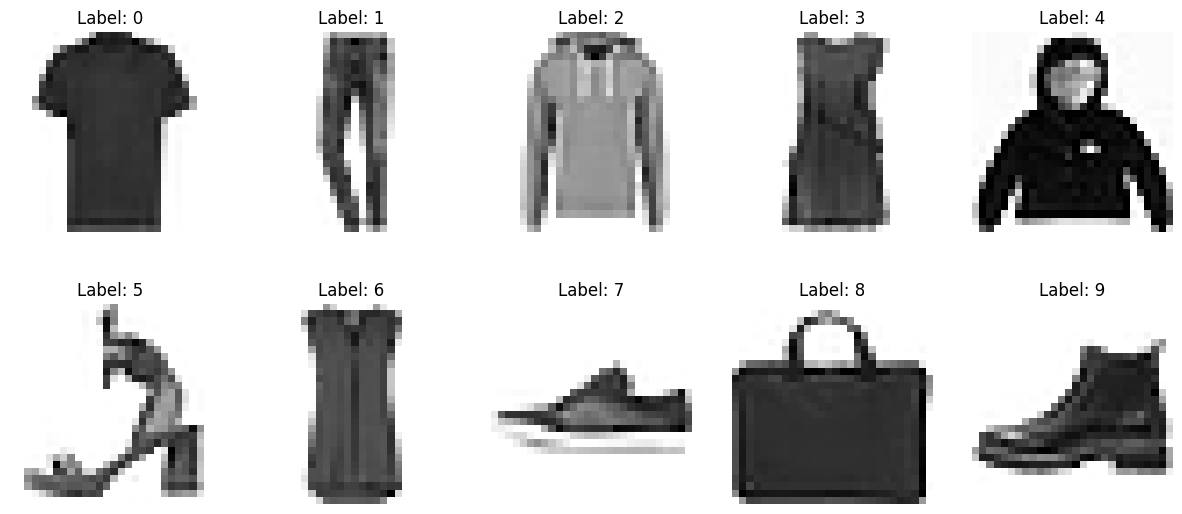

In [5]:
unique_labels = np.unique(train_labels)

plt.figure(figsize=(15, 10))
for i, label in enumerate(unique_labels):
    plt.subplot(3, 5, i + 1)
    image = train_images[train_labels == label][0]
    plt.imshow(image, cmap='binary')
    plt.title(f'Label: {label}')
    plt.axis('off')
plt.show()

By observing the images, the labels can be identified as follows:
1. 0 - T-shirt/top
2. 1 - Trouser
3. 2 - Pullover
4. 3 - Dress
5. 4 - Coat
6. 5 - Sandal
7. 6 - Shirt
8. 7 - sneaker
9. 8 - Bag
10. 9 - Boot

In [6]:
train_len = int(len(train_images) * 0.8)
train_x, val_x = train_images[:train_len], train_images[train_len:]
train_y, val_y = train_labels[:train_len], train_labels[train_len:]
train_images = train_x
train_labels = train_y
val_images = val_x
val_labels = val_y

### Model Implementation and Training

In [6]:
class Model(nn.Module):
    def __init__(self, input_size=28 * 28, num_classes=10, hidden_size=256, hidden_size2=128, dropout=0.2):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, num_classes)
        self.relu = nn.ReLU()
        self.input_size = input_size

    def forward(self, x):
        x = x.view(-1, self.input_size)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

In [7]:
model1_train = train_images.reshape(-1, 28 * 28)
model1_test = test_images.reshape(-1, 28 * 28)
model1_val = val_images.reshape(-1, 28 * 28)

In [57]:
train_tensor = torch.tensor(model1_train, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.int64)
test_tensor = torch.tensor(model1_test, dtype=torch.float32)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.int64)
val_tensor = torch.tensor(model1_val, dtype=torch.float32)
val_labels_tensor = torch.tensor(val_labels, dtype=torch.int64)

train_dataset = TensorDataset(train_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_tensor, test_labels_tensor)
val_dataset = TensorDataset(val_tensor, val_labels_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)
val_loader = DataLoader(val_dataset, batch_size=64)
    
model1 = Model()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=0.001)

Epoch 1, Loss: 0.8949424440860748
Validation Loss: 0.5658233636554252
Epoch 2, Loss: 0.5493166985313097
Validation Loss: 0.4441148436608467
Epoch 3, Loss: 0.4968165549039841
Validation Loss: 0.41028277980203326
Epoch 4, Loss: 0.4687078113555908
Validation Loss: 0.4160904531624723
Epoch 5, Loss: 0.458775147040685
Validation Loss: 0.40858473850691573
Epoch 6, Loss: 0.4430758290489515
Validation Loss: 0.43424886369958837
Epoch 7, Loss: 0.4343582825064659
Validation Loss: 0.41295945557191016
Epoch 8, Loss: 0.42484995504220324
Validation Loss: 0.4081369438704024
Epoch 9, Loss: 0.4134655397137006
Validation Loss: 0.40045852990860636
Epoch 10, Loss: 0.4076339870293935
Validation Loss: 0.37858621435279544


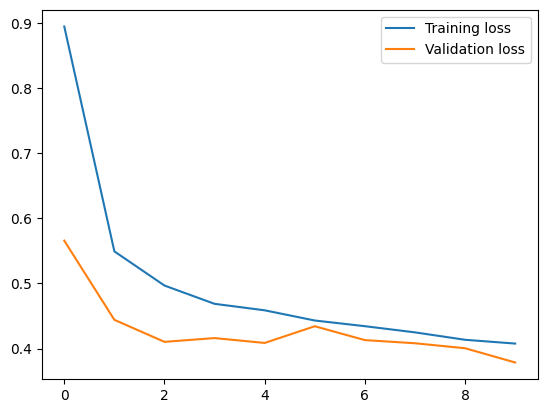

Accuracy: 0.8679


In [25]:
epochs = 10
train_losses, val_losses = [], []
for epoch in range(epochs):
    running_loss = 0.0
    model1.train()
    for data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model1(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(train_loader)}")
    train_losses.append(running_loss / len(train_loader))

    val_loss = 0.0
    model1.eval()
    for data, labels in val_loader:
        outputs = model1(data)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
    print(f"Validation Loss: {val_loss / len(val_loader)}")
    val_losses.append(val_loss / len(val_loader))

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.show()

correct = 0
total = 0
with torch.no_grad():
    for data, labels in test_loader:
        outputs = model1(data)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {correct / total}")

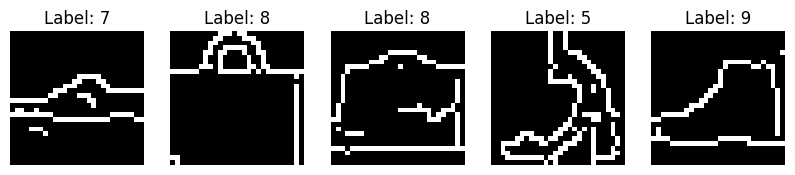

In [11]:
def preprocess_image(image):
    
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    elif len(image.shape) == 2:
        gray = image
    
    if gray.dtype != np.uint8:
        gray = gray.astype(np.uint8)
    
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    edges = cv2.Canny(blurred, 50, 150)
    
    return edges

train_images_edges = np.array([preprocess_image(image) for image in train_images])
test_images_edges = np.array([preprocess_image(image) for image in test_images])
val_images_edges = np.array([preprocess_image(image) for image in val_images])

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(train_images_edges[i], cmap='gray')
    plt.title(f'Label: {train_labels[i]}')
    plt.axis('off')
plt.show()

In [12]:
model2_train = train_images_edges.reshape(-1, 28 * 28)
model2_test = test_images_edges.reshape(-1, 28 * 28)
model2_val = val_images_edges.reshape(-1, 28 * 28)

In [47]:
train_tensor = torch.tensor(model2_train, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.int64)

test_tensor = torch.tensor(model2_test, dtype=torch.float32)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.int64)

val_tensor = torch.tensor(model2_val, dtype=torch.float32)
val_labels_tensor = torch.tensor(val_labels, dtype=torch.int64)

train_dataset = TensorDataset(train_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_tensor, test_labels_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

Epoch 1, Loss: 0.8124787078698477
Validation Loss: 0.4960295571263429
Epoch 2, Loss: 0.4819175468881925
Validation Loss: 0.4572738021801991
Epoch 3, Loss: 0.4311376601258914
Validation Loss: 0.45594589734912677
Epoch 4, Loss: 0.39666353386640546
Validation Loss: 0.43999197841829557
Epoch 5, Loss: 0.37174036500851315
Validation Loss: 0.4582532332960967
Epoch 6, Loss: 0.34675642295678455
Validation Loss: 0.464021482048141
Epoch 7, Loss: 0.33307674688100813
Validation Loss: 0.45458568186516973
Epoch 8, Loss: 0.31259693193932375
Validation Loss: 0.4563036359799136
Epoch 9, Loss: 0.29083882120251653
Validation Loss: 0.4738064031502244
Epoch 10, Loss: 0.27911286090314386
Validation Loss: 0.4932983412294631


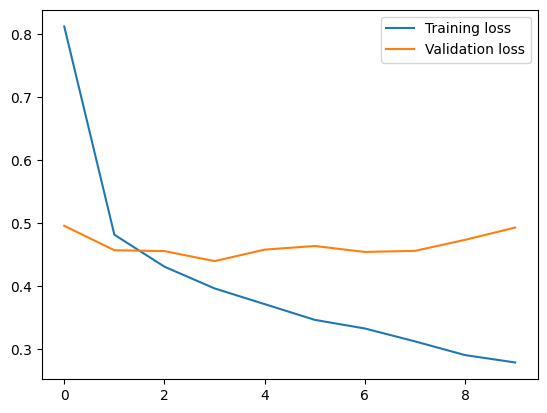

Accuracy: 0.8423


In [28]:
model2 = Model()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001)

epochs = 10
train_losses, val_losses = [], []

for epoch in range(epochs):
    running_loss = 0.0
    model2.train()
    for data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model2(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(train_loader)}")
    train_losses.append(running_loss / len(train_loader))

    val_loss = 0.0
    model2.eval()
    for data, labels in test_loader:
        outputs = model2(data)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
    print(f"Validation Loss: {val_loss / len(test_loader)}")
    val_losses.append(val_loss / len(test_loader))

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.show()

correct = 0
total = 0
with torch.no_grad():
    for data, labels in test_loader:
        outputs = model2(data)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {correct / total}")

In [14]:
def hog_features(images):
    return np.array([hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=False) for img in images])


train_images_hog = hog_features(train_images)
test_images_hog = hog_features(test_images)
val_images_hog = hog_features(val_images)

model3_train = train_images_hog
model3_test = test_images_hog
model3_val = val_images_hog

In [ ]:
train_tensor = torch.tensor(model3_train, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.int64)

test_tensor = torch.tensor(model3_test, dtype=torch.float32)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.int64)

val_tensor = torch.tensor(model3_val, dtype=torch.float32)
val_labels_tensor = torch.tensor(val_labels, dtype=torch.int64)

train_dataset = TensorDataset(train_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_tensor, test_labels_tensor)
val_dataset = TensorDataset(val_tensor, val_labels_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)
val_loader = DataLoader(val_dataset, batch_size=64)

Epoch 1, Loss: 0.7205253304243088
Validation Loss: 0.5391316846647161
Epoch 2, Loss: 0.5218386265039444
Validation Loss: 0.5041105222511799
Epoch 3, Loss: 0.48209554876883826
Validation Loss: 0.4723773056522329
Epoch 4, Loss: 0.4602839956283569
Validation Loss: 0.46443428138786175
Epoch 5, Loss: 0.4443317988912264
Validation Loss: 0.4541382648526354
Epoch 6, Loss: 0.42967545068264007
Validation Loss: 0.4429112171873133
Epoch 7, Loss: 0.41747907682259877
Validation Loss: 0.4361831110684162
Epoch 8, Loss: 0.40589689679940544
Validation Loss: 0.4293267527159224
Epoch 9, Loss: 0.3982305040756861
Validation Loss: 0.42134402755727157
Epoch 10, Loss: 0.3908961288730303
Validation Loss: 0.41622259444061743


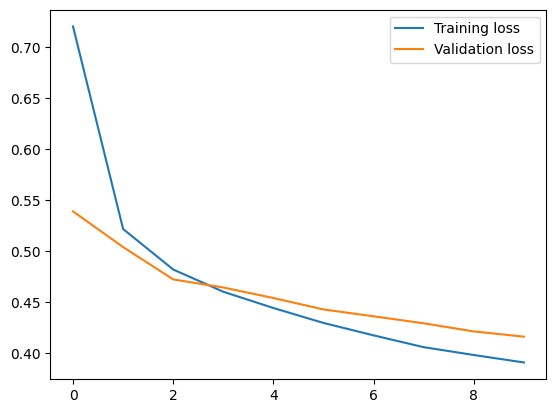

Accuracy: 0.8586


In [33]:
model3 = Model(input_size=144)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model3.parameters(), lr=0.001)

epochs = 10
train_losses, val_losses = [], []

for epoch in range(epochs):
    running_loss = 0.0
    model3.train()
    for data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model3(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(train_loader)}")
    train_losses.append(running_loss / len(train_loader))

    val_loss = 0.0
    model3.eval()
    for data, labels in val_loader:
        outputs = model3(data)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
    print(f"Validation Loss: {val_loss / len(val_loader)}")
    val_losses.append(val_loss / len(val_loader))

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.show()

total = 0
correct = 0

with torch.no_grad():
    for data, labels in test_loader:
        outputs = model3(data)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {correct / total}")

In [44]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    model.train()
    for epoch in range(epochs):
        for data, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, labels in val_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total, model

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

def evaluate(model, train_loader, val_loader, test_loader):

    model.eval()
    train_preds = []
    train_labels = []
    with torch.no_grad():
        for data, labels in train_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            train_preds.extend(predicted.numpy())
            train_labels.extend(labels.numpy())
    
    val_preds = []
    val_labels = []
    with torch.no_grad():
        for data, labels in val_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            val_preds.extend(predicted.numpy())
            val_labels.extend(labels.numpy())

    test_preds = []
    test_labels = []

    with torch.no_grad():
        for data, labels in test_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            test_preds.extend(predicted.numpy())
            test_labels.extend(labels.numpy())

    train_acc = np.mean(np.array(train_preds) == np.array(train_labels))
    val_acc = np.mean(np.array(val_preds) == np.array(val_labels))
    test_acc = np.mean(np.array(test_preds) == np.array(test_labels))

    train_precision = precision_score(train_labels, train_preds, average='weighted')
    val_precision = precision_score(val_labels, val_preds, average='weighted')
    test_precision = precision_score(test_labels, test_preds, average='weighted')

    train_recall = recall_score(train_labels, train_preds, average='weighted')
    val_recall = recall_score(val_labels, val_preds, average='weighted')
    test_recall = recall_score(test_labels, test_preds, average='weighted')

    train_f1 = f1_score(train_labels, train_preds, average='weighted')
    val_f1 = f1_score(val_labels, val_preds, average='weighted')
    test_f1 = f1_score(test_labels, test_preds, average='weighted')

    train_confusion = confusion_matrix(train_labels, train_preds)
    val_confusion = confusion_matrix(val_labels, val_preds)
    test_confusion = confusion_matrix(test_labels, test_preds)

    # print the evaluation metrics
    print("Train Accuracy: ", train_acc)
    print("Validation Accuracy: ", val_acc)
    print("Test Accuracy: ", test_acc)

    print("Train Precision: ", train_precision)
    print("Validation Precision: ", val_precision)
    print("Test Precision: ", test_precision)

    print("Train Recall: ", train_recall)
    print("Validation Recall: ", val_recall)
    print("Test Recall: ", test_recall)

    print("Train F1 Score: ", train_f1)
    print("Validation F1 Score: ", val_f1)
    print("Test F1 Score: ", test_f1)

    print("Train Confusion Matrix: ")

    sns.heatmap(train_confusion, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print("Validation Confusion Matrix: ")
    sns.heatmap(val_confusion, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print("Test Confusion Matrix: ")
    sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## Plots and Performance Visualizations

In [ ]:
train_tensor = torch.tensor(model1_train, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.int64)
val_tensor = torch.tensor(model1_val, dtype=torch.float32)
val_labels_tensor = torch.tensor(val_labels, dtype=torch.int64)

train_dataset = TensorDataset(train_tensor, train_labels_tensor)
val_dataset = TensorDataset(val_tensor, val_labels_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
    
sweep_config = {
    'method': 'grid',
    'parameters': {
        'epochs': {
            'values': [5, 10]
        },
        'dropout': {
            'values': [0.1, 0.2, 0.3]
        },
        'hidden_dim1': {
            'values': [64, 128, 256]
        },
        'hidden_dim2': {
            'values': [64, 128, 256]
        }
    },
    'metric': { 'name': 'val_accuracy', 'goal': 'maximize' }
}

sweep_id = wandb.sweep(sweep_config, project='image_classification')

def train():
    config_defaults = {
        'epochs': 5,
        'dropout': 0.2,
        'hidden_dim1': 128,
        'hidden_dim2': 64
    }

    wandb.init(config=config_defaults)

    config = wandb.config

    model = Model(hidden_size=config.hidden_dim1, hidden_size2=config.hidden_dim2, dropout=config.dropout)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    val_accuracy, model = train_model(model, train_loader, val_loader, criterion, optimizer, config.epochs)

    wandb.log({"epochs": config.epochs, "dropout": config.dropout, "hidden_dim1": config.hidden_dim1, "hidden_dim2": config.hidden_dim2, "val_accuracy": val_accuracy})
    wandb.finish()

wandb.agent(sweep_id, function=train)


#### Best hyperparameters for model 1
1. Epochs - 10
2. hidden dim 1 - 128
3. hidden dim 2 - 64
4. dropout - 0.1

### BEST MODEL 1

Epoch 1, Loss: 0.7705477490623792
Validation Loss: 0.5026280209422112
Epoch 2, Loss: 0.4875028624534607
Validation Loss: 0.4507573698746397
Epoch 3, Loss: 0.44638286099831265
Validation Loss: 0.4092844696913628
Epoch 4, Loss: 0.42495585016409554
Validation Loss: 0.39343656195288007
Epoch 5, Loss: 0.41319964587688446
Validation Loss: 0.4087447539130424
Epoch 6, Loss: 0.4018920581936836
Validation Loss: 0.41596048333226365
Epoch 7, Loss: 0.39793561071157457
Validation Loss: 0.3882311644389274
Epoch 8, Loss: 0.3842228182951609
Validation Loss: 0.38108055166741633
Epoch 9, Loss: 0.3804703350464503
Validation Loss: 0.37307355410241066
Epoch 10, Loss: 0.369916156232357
Validation Loss: 0.39384504320456626


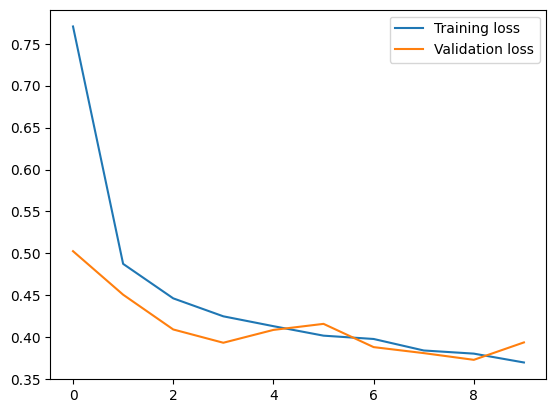

Train Accuracy:  0.879375
Validation Accuracy:  0.8640833333333333
Test Accuracy:  0.8673
Train Precision:  0.8800153375126908
Validation Precision:  0.8651077898817147
Test Precision:  0.8675420575465763
Train Recall:  0.879375
Validation Recall:  0.8640833333333333
Test Recall:  0.8673
Train F1 Score:  0.8770562094237632
Validation F1 Score:  0.8620107409895486
Test F1 Score:  0.8648748401056704
Train Confusion Matrix: 


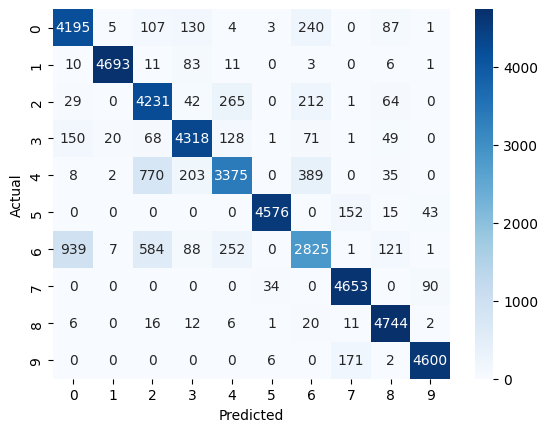

Validation Confusion Matrix: 


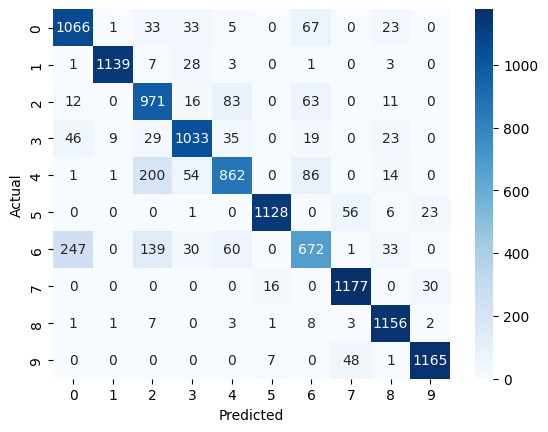

Test Confusion Matrix: 


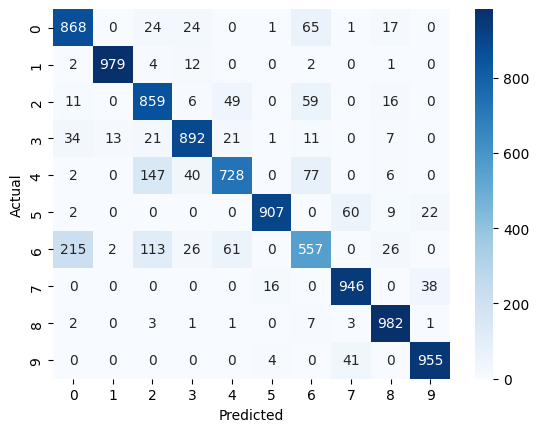

In [10]:
train_tensor = torch.tensor(model1_train, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.int64)
val_tensor = torch.tensor(model1_val, dtype=torch.float32)
val_labels_tensor = torch.tensor(val_labels, dtype=torch.int64)
test_tensor = torch.tensor(model1_test, dtype=torch.float32)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.int64)

train_dataset = TensorDataset(train_tensor, train_labels_tensor)
val_dataset = TensorDataset(val_tensor, val_labels_tensor)
test_dataset = TensorDataset(test_tensor, test_labels_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

model = Model(dropout=0.1, hidden_size=128, hidden_size2=64)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses, val_losses = [], []

for epoch in range(epochs):
    running_loss = 0.0
    model.train()
    for data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(train_loader)}")
    train_losses.append(running_loss / len(train_loader))

    val_loss = 0.0
    model.eval()
    for data, labels in val_loader:
        outputs = model(data)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
    print(f"Validation Loss: {val_loss / len(val_loader)}")
    val_losses.append(val_loss / len(val_loader))

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.show()

evaluate(model, train_loader, val_loader, test_loader)


In [ ]:
train_tensor = torch.tensor(model2_train, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.int64)
val_tensor = torch.tensor(model2_val, dtype=torch.float32)
val_labels_tensor = torch.tensor(val_labels, dtype=torch.int64)

train_dataset = TensorDataset(train_tensor, train_labels_tensor)
val_dataset = TensorDataset(val_tensor, val_labels_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
    
sweep_config = {
    'method': 'grid',
    'parameters': {
        'epochs': {
            'values': [5, 10]
        },
        'dropout': {
            'values': [0.1, 0.2, 0.3]
        },
        'hidden_dim1': {
            'values': [64, 128, 256]
        },
        'hidden_dim2': {
            'values': [64, 128, 256]
        }
    },
    'metric': { 'name': 'val_accuracy', 'goal': 'maximize' }
}

sweep_id = wandb.sweep(sweep_config, project='image_classification')

def train():
    config_defaults = {
        'epochs': 5,
        'dropout': 0.2,
        'hidden_dim1': 128,
        'hidden_dim2': 64
    }

    wandb.init(config=config_defaults)

    config = wandb.config

    model = Model(hidden_size=config.hidden_dim1, hidden_size2=config.hidden_dim2, dropout=config.dropout)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    val_accuracy, model = train_model(model, train_loader, val_loader, criterion, optimizer, config.epochs)

    wandb.log({"epochs": config.epochs, "dropout": config.dropout, "hidden_dim1": config.hidden_dim1, "hidden_dim2": config.hidden_dim2, "val_accuracy": val_accuracy})
    wandb.finish()

wandb.agent(sweep_id, function=train)


#### Best hyperparameters for model 2
1. Epochs - 10
2. hidden dim 1 - 256
3. hidden dim 2 - 256
4. dropout - 0.3

### BEST MODEL 2

Epoch 1, Loss: 0.9921895373264948
Validation Loss: 0.5822999044618709
Epoch 2, Loss: 0.5644753595789274
Validation Loss: 0.5063263033615782
Epoch 3, Loss: 0.4868100854754448
Validation Loss: 0.4724655629314007
Epoch 4, Loss: 0.45628523780902225
Validation Loss: 0.48852863424318904
Epoch 5, Loss: 0.43411113009850183
Validation Loss: 0.48039171575231754
Epoch 6, Loss: 0.42202373574177426
Validation Loss: 0.45781479894797855
Epoch 7, Loss: 0.4041641199787458
Validation Loss: 0.48464864738127017
Epoch 8, Loss: 0.3910142454703649
Validation Loss: 0.4761231779418093
Epoch 9, Loss: 0.37796164231499035
Validation Loss: 0.46538283097300126
Epoch 10, Loss: 0.363979065100352
Validation Loss: 0.49627581936247805


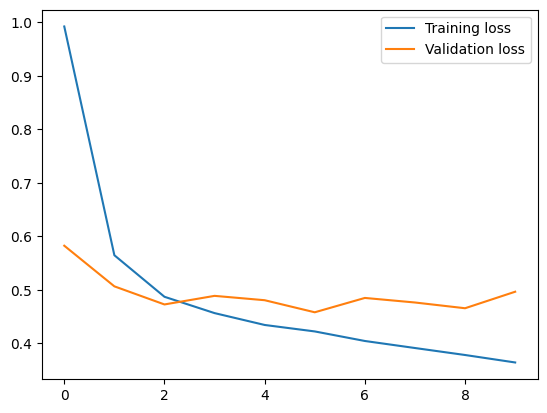

Train Accuracy:  0.8997708333333333
Validation Accuracy:  0.8325833333333333
Test Accuracy:  0.8352
Train Precision:  0.9004684453938925
Validation Precision:  0.8324041174887029
Test Precision:  0.8341849460063826
Train Recall:  0.8997708333333333
Validation Recall:  0.8325833333333333
Test Recall:  0.8352
Train F1 Score:  0.8979209959550162
Validation F1 Score:  0.830462494793435
Test F1 Score:  0.8325987109702355
Train Confusion Matrix: 


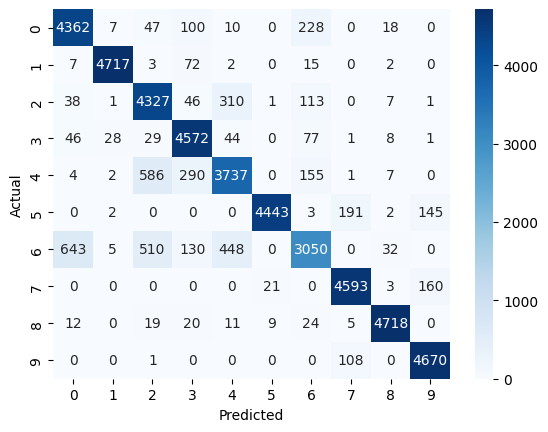

Validation Confusion Matrix: 


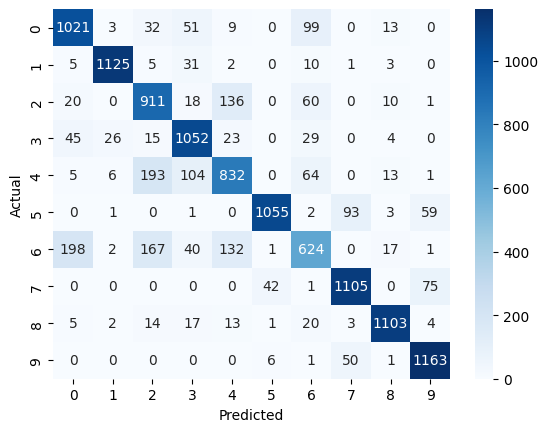

Test Confusion Matrix: 


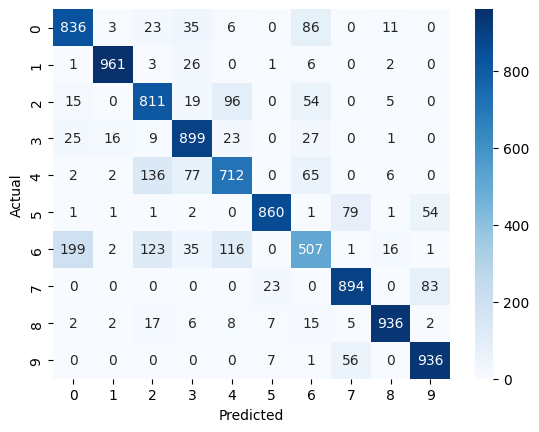

In [13]:
train_tensor = torch.tensor(model2_train, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.int64)
val_tensor = torch.tensor(model2_val, dtype=torch.float32)
val_labels_tensor = torch.tensor(val_labels, dtype=torch.int64)
test_tensor = torch.tensor(model2_test, dtype=torch.float32)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.int64)

train_dataset = TensorDataset(train_tensor, train_labels_tensor)
val_dataset = TensorDataset(val_tensor, val_labels_tensor)
test_dataset = TensorDataset(test_tensor, test_labels_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

model = Model(dropout=0.3, hidden_size=256, hidden_size2=256)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses, val_losses = [], []

for epoch in range(epochs):
    running_loss = 0.0
    model.train()
    for data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(train_loader)}")
    train_losses.append(running_loss / len(train_loader))

    val_loss = 0.0
    model.eval()
    for data, labels in val_loader:
        outputs = model(data)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
    print(f"Validation Loss: {val_loss / len(val_loader)}")
    val_losses.append(val_loss / len(val_loader))

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.show()

evaluate(model, train_loader, val_loader, test_loader)


In [ ]:
train_tensor = torch.tensor(model3_train, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.int64)
val_tensor = torch.tensor(model3_val, dtype=torch.float32)
val_labels_tensor = torch.tensor(val_labels, dtype=torch.int64)

train_dataset = TensorDataset(train_tensor, train_labels_tensor)
val_dataset = TensorDataset(val_tensor, val_labels_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
    
sweep_config = {
    'method': 'grid',
    'parameters': {
        'epochs': {
            'values': [5, 10]
        },
        'dropout': {
            'values': [0.1, 0.2, 0.3]
        },
        'hidden_dim1': {
            'values': [64, 128, 256]
        },
        'hidden_dim2': {
            'values': [64, 128, 256]
        }
    },
    'metric': { 'name': 'val_accuracy', 'goal': 'maximize' }
}

sweep_id = wandb.sweep(sweep_config, project='image_classification')

def train():
    config_defaults = {
        'epochs': 5,
        'dropout': 0.2,
        'hidden_dim1': 128,
        'hidden_dim2': 64
    }

    wandb.init(config=config_defaults)

    config = wandb.config

    model = Model(input_size=144,hidden_size=config.hidden_dim1, hidden_size2=config.hidden_dim2, dropout=config.dropout)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    val_accuracy, model = train_model(model, train_loader, val_loader, criterion, optimizer, config.epochs)

    wandb.log({"epochs": config.epochs, "dropout": config.dropout, "hidden_dim1": config.hidden_dim1, "hidden_dim2": config.hidden_dim2, "val_accuracy": val_accuracy})
    wandb.finish()

wandb.agent(sweep_id, function=train)

#### Best hyperparameters for model 1
1. Epochs - 10
2. hidden dim 1 - 256
3. hidden dim 2 - 256
4. dropout - 0.1

### BEST MODEL 3

Epoch 1, Loss: 0.6966908409198125
Validation Loss: 0.5455782405556516
Epoch 2, Loss: 0.5086018545627594
Validation Loss: 0.4994359567285852
Epoch 3, Loss: 0.4673490686615308
Validation Loss: 0.4774799087738737
Epoch 4, Loss: 0.4457934463818868
Validation Loss: 0.45479444628383253
Epoch 5, Loss: 0.4256861633658409
Validation Loss: 0.44654824077448946
Epoch 6, Loss: 0.4119836182594299
Validation Loss: 0.43464202156409304
Epoch 7, Loss: 0.3988217428425948
Validation Loss: 0.42795125949890056
Epoch 8, Loss: 0.3880709364811579
Validation Loss: 0.4198829470638265
Epoch 9, Loss: 0.3756757023135821
Validation Loss: 0.4209171341771775
Epoch 10, Loss: 0.366407546967268
Validation Loss: 0.4104432516751137


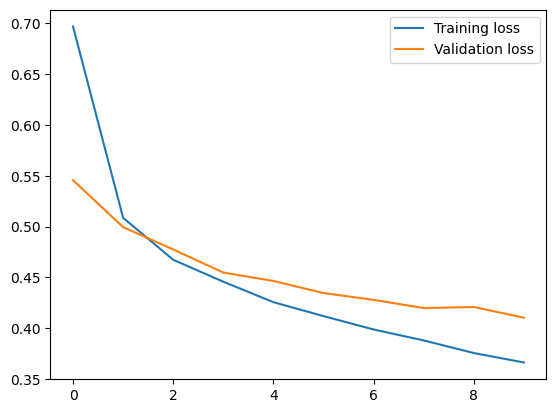

Train Accuracy:  0.8708958333333333
Validation Accuracy:  0.8475
Test Accuracy:  0.8609
Train Precision:  0.8715263769779514
Validation Precision:  0.8476615885324199
Test Precision:  0.8614786390479249
Train Recall:  0.8708958333333333
Validation Recall:  0.8475
Test Recall:  0.8609
Train F1 Score:  0.8694256294256746
Validation F1 Score:  0.8455852888702402
Test F1 Score:  0.8592769885659838
Train Confusion Matrix: 


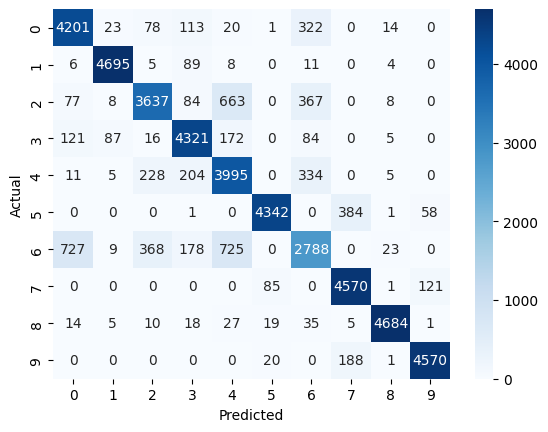

Validation Confusion Matrix: 


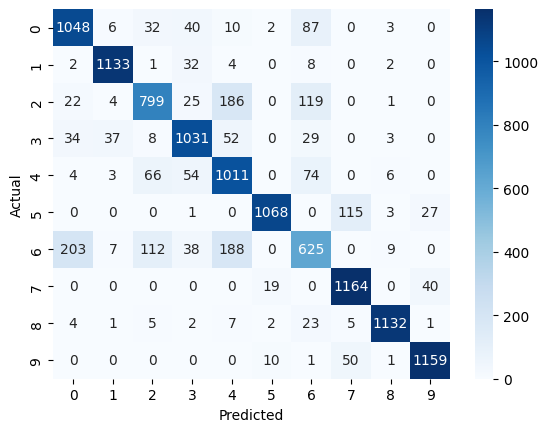

Test Confusion Matrix: 


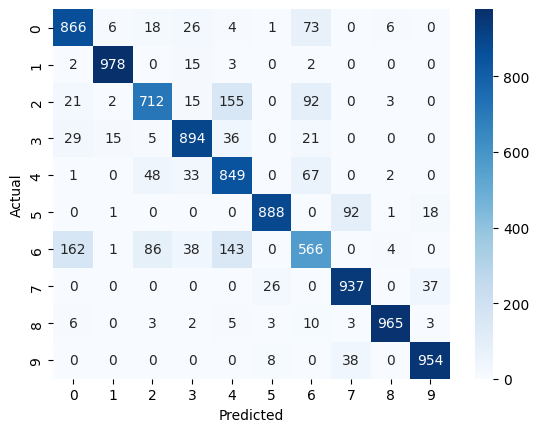

In [15]:
train_tensor = torch.tensor(model3_train, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.int64)
val_tensor = torch.tensor(model3_val, dtype=torch.float32)
val_labels_tensor = torch.tensor(val_labels, dtype=torch.int64)
test_tensor = torch.tensor(model3_test, dtype=torch.float32)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.int64)

train_dataset = TensorDataset(train_tensor, train_labels_tensor)
val_dataset = TensorDataset(val_tensor, val_labels_tensor)
test_dataset = TensorDataset(test_tensor, test_labels_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

model = Model(input_size=144, dropout=0.1, hidden_size=256, hidden_size2=256)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses, val_losses = [], []

for epoch in range(epochs):
    running_loss = 0.0
    model.train()
    for data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(train_loader)}")
    train_losses.append(running_loss / len(train_loader))

    val_loss = 0.0
    model.eval()
    for data, labels in val_loader:
        outputs = model(data)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
    print(f"Validation Loss: {val_loss / len(val_loader)}")
    val_losses.append(val_loss / len(val_loader))

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.show()

evaluate(model, train_loader, val_loader, test_loader)


### Observations

- **Model 1** performed the best, with the highest validation accuracy and lowest validation loss. This shows that using raw images worked well for the task.  
- **Model 2** had inconsistent validation loss, likely because edge detection added extra noise or complexity that made it harder for the model to perform well.  
- **Model 3** achieved accuracy similar to Model 1, showing that HOG features can be useful, but they weren’t better than using raw images.  

| Model       | Accuracy | Precision | Recall | F1-score |
|-------------|----------|-----------|--------|----------|
| Model 1     | 0.8673   | 0.8675    | 0.8673 | 0.8648   |
| Model 2     | 0.8352   | 0.8341    | 0.8352 | 0.8325   |
| Model 3     | 0.8609   | 0.8614    | 0.8609 | 0.8592   |

### Observations

- The confusion matrix shows that the models struggled to differentiate between similar classes like **T-shirt (0)**, **Pullover (2)**, **Coat (4)**, and **Dress (6)**, which is understandable.  
- The models performed well on classes with distinct features, such as **Sandal**, **Bag**, and **Boot**.   

## 4.4 Analysis and Logical Comparison

- **Model 1** performed the best, followed by **Model 3** and then **Model 2**.  
- This suggests that **raw images** are the most effective for classification, followed by **HOG features**, while **edge detection features** were the least effective.  
- Raw images include the most detail and information, which likely helped Model 1 outperform the others.  
- HOG features focus on shapes and textures, making them useful but not as powerful as raw images.  
- Edge detection might have added unnecessary complexity or noise, as seen from the unstable validation loss in Model 2.

#### Feature Comparison:

- **Raw Images:**  
  - Best for tasks needing detailed information, like complex objects or scenes with significant color and texture variations.  
  - Useful when lighting and color changes are important in the dataset.  

- **Canny Edge Detection:**  
  - Good for tasks focused on shapes and edges, such as object detection, where background details can be ignored.  
  - Helps simplify images by emphasizing outlines instead of finer details.  

- **HOG Features:**  
  - Effective for recognizing shapes or patterns, like in pedestrian detection or character recognition tasks.  
  - Works well when reducing dimensionality while keeping essential structural details.  


### Model 1 hyperparameter tuning

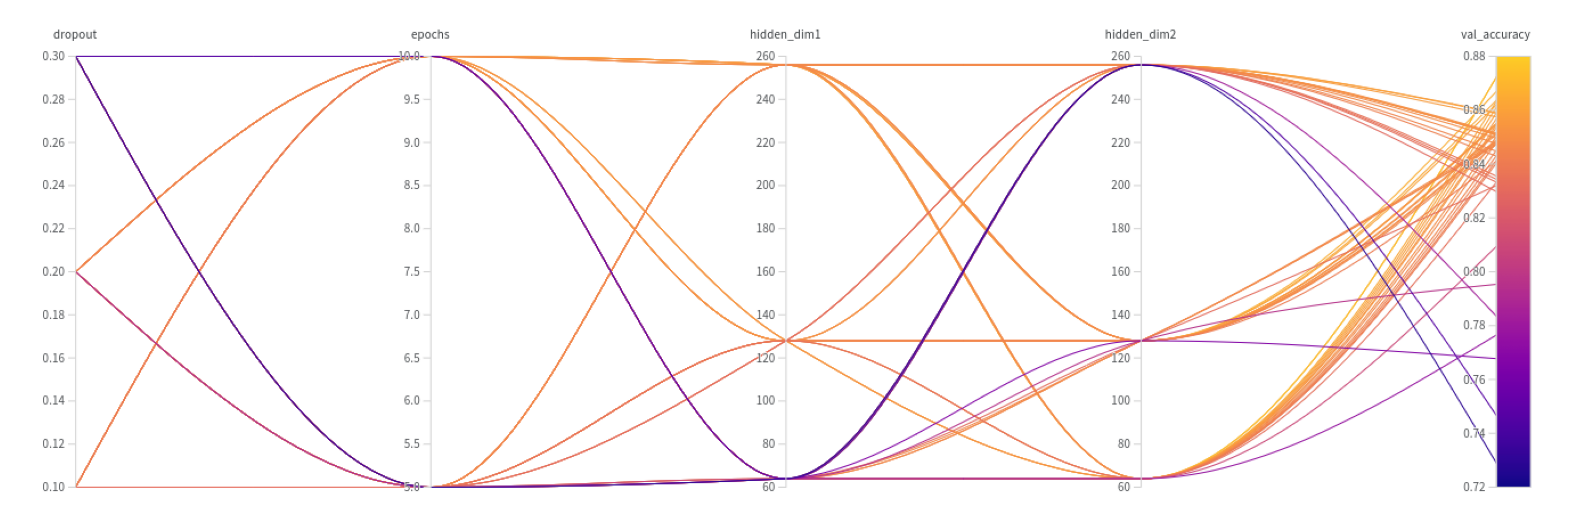

In [14]:
image = cv2.imread('1.png', cv2.IMREAD_COLOR_RGB)
plt.figure(figsize=(20,20))
plt.imshow(image)
plt.axis('off')
plt.show()

### Model 2 hyperparameter tuning

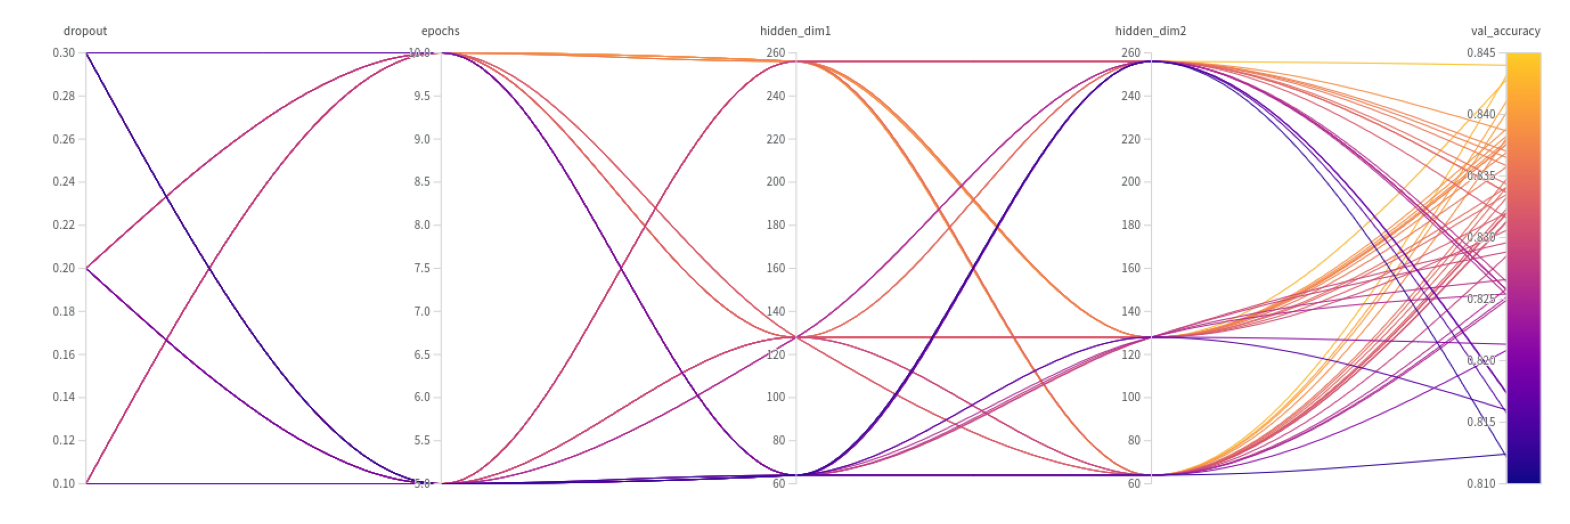

In [15]:
image = cv2.imread('2.png', cv2.IMREAD_COLOR_RGB)
plt.figure(figsize=(20,20))
plt.imshow(image)
plt.axis('off')
plt.show()

### Model 3 hyperparameter tuning

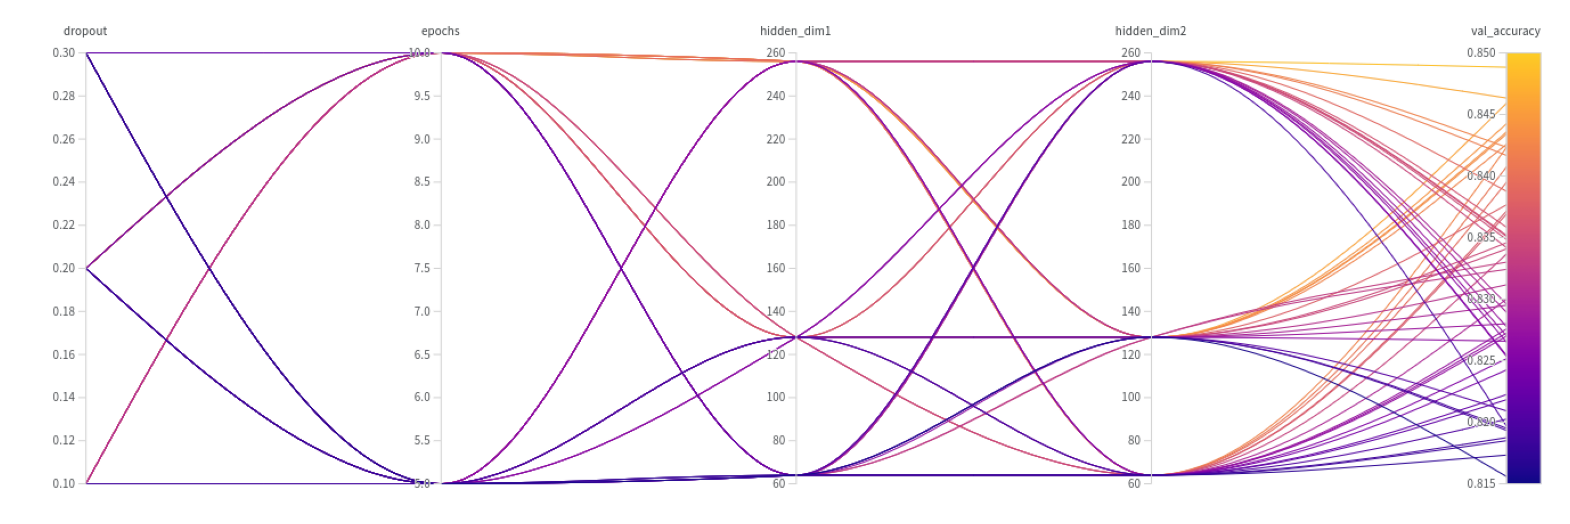

In [16]:
image = cv2.imread('3.png', cv2.IMREAD_COLOR_RGB)
plt.figure(figsize=(20,20))
plt.imshow(image)
plt.axis('off')
plt.show()